In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Part I: Analyzing US baby name trends

The SSA has made available data on the frequency of baby names from 1880 through 2021 (at the time of this writing).
The raw data can be obtained from [the SSA webpage](https://www.ssa.gov/oact/babynames/limits.html) (there is one file per year).

**Part 0:** Download the [National Data](https://www.ssa.gov/oact/babynames/names.zip) file *names.zip* and unzip it.

**Part 1** Assemble all of the data into a single DataFrame and add a *year* field. 
You can do this using [pandas.concat](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html)

In [2]:
years = list(range(1880,2021))

In [3]:
df_list = []
for year in years:
    # load the dataset into a dataframe
    df = pd.read_csv('names/yob'+str(year)+'.txt',header=None,names=['name','sex','births'])
    # add year column
    df['year'] = year
    # put dataframe in df_list
    df_list.append(df)
names = pd.concat(df_list)
names.head()

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


**Part 2:** Plot the total births by sex and year

<AxesSubplot:xlabel='year'>

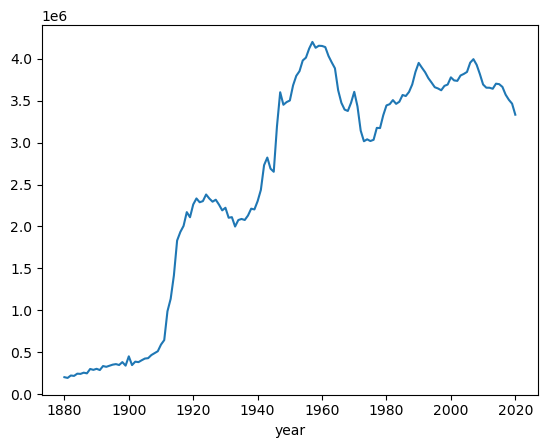

In [18]:
names.groupby('year').births.sum().plot()

**Part 3:** Plot the number of babies given a particular name (your own, or another name) by year.

<AxesSubplot:xlabel='year'>

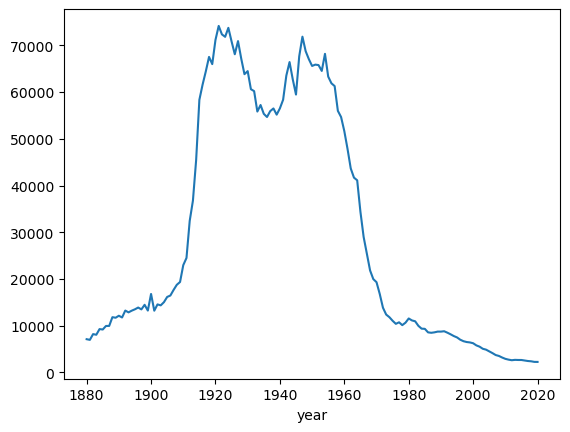

In [17]:
names[names.name == 'Mary'].groupby('year').births.sum().plot()

**Part 4:** Insert a column 'prop' with the relative frequency of each name in each of the years.

In [22]:
yearly = names.groupby('year').births.sum()
yearly

year
1880     201484
1881     192690
1882     221533
1883     216945
1884     243461
         ...   
2016    3665860
2017    3572758
2018    3511750
2019    3465821
2020    3333981
Name: births, Length: 141, dtype: int64

In [47]:
yearly = yearly.to_dict()

In [48]:
names['prop'] = names.year.replace(yearly)

In [50]:
names['prop'] = names.births / names.prop

In [51]:
names

,name,sex,births,year,prop
0,Mary,F,7065,1880,0.035065
1,Anna,F,2604,1880,0.012924
2,Emma,F,2003,1880,0.009941
3,Elizabeth,F,1939,1880,0.009624
4,Minnie,F,1746,1880,0.008666
...,...,...,...,...,...
31512,Zykier,M,5,2020,0.000001
31513,Zylus,M,5,2020,0.000001
31514,Zymari,M,5,2020,0.000001
31515,Zyn,M,5,2020,0.000001


This was sooooo slow when iterating over rows and almsot instantaneous with this vectorized approach

**Part 5**: Create a DataFrame 'top1000_names' that contains the top 1000 names for each sex/year combination.
You will use this top 1000 dataset in the following investigations into the data.

In [73]:
names['top_cutoff'] = names['prop']

In [75]:
namesF = names[names.sex=='F']
namesM = names[names.sex=='M']

In [78]:
cutoff_keyM = {}
cutoff_keyF = {}
for year in range(1880,2021):
    #check to see if there are 1000 names for year/sex combo
    if namesF[namesF.year == year].name.count() <1000:
        valF = 0
    else: 
        valF = namesF[namesF.year == year].prop.sort_values(ascending=False, ignore_index=True)[999]
        
    if namesM[namesM.year == year].name.count() <1000:
        valM = 0
    else: 
        valM = namesM[namesM.year == year].prop.sort_values(ascending=False, ignore_index=True)[999]
    
    cutoff_keyF[year] = valF
    cutoff_keyM[year] = valM

In [83]:
namesF.loc[:,'top_cutoff'] = namesF.year.replace(cutoff_keyF)
namesM.loc[:,'top_cutoff'] = namesM.year.replace(cutoff_keyM)

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [85]:
namesM

,name,sex,births,year,prop,top_cutoff
942,John,M,9655,1880,0.047919,0.000025
943,William,M,9532,1880,0.047309,0.000025
944,James,M,5927,1880,0.029417,0.000025
945,Charles,M,5348,1880,0.026543,0.000025
946,George,M,5126,1880,0.025441,0.000025
...,...,...,...,...,...,...
31512,Zykier,M,5,2020,0.000001,0.000064
31513,Zylus,M,5,2020,0.000001,0.000064
31514,Zymari,M,5,2020,0.000001,0.000064
31515,Zyn,M,5,2020,0.000001,0.000064


In [92]:
top1000_names = pd.concat([namesM[namesM.prop>=namesM.top_cutoff],namesF[namesF.prop>=namesF.top_cutoff]],
                          ignore_index=True).sort_values(['year','sex']).drop('top_cutoff', axis=1)

In [93]:
top1000_names

,name,sex,births,year,prop
143408,Mary,F,7065,1880,0.035065
143409,Anna,F,2604,1880,0.012924
143410,Emma,F,2003,1880,0.009941
143411,Elizabeth,F,1939,1880,0.009624
143412,Minnie,F,1746,1880,0.008666
...,...,...,...,...,...
143403,Keenan,M,214,2020,0.000064
143404,Jericho,M,213,2020,0.000064
143405,Rogelio,M,213,2020,0.000064
143406,Karim,M,212,2020,0.000064


In [96]:
len(top1000_names)/(2021-1880) # this number being around 2000 is heartening 

2024.2553191489362

**Part 6**: Plot the number of Johns, Harrys, Marys, and Marilyns by year.

<AxesSubplot:xlabel='year'>

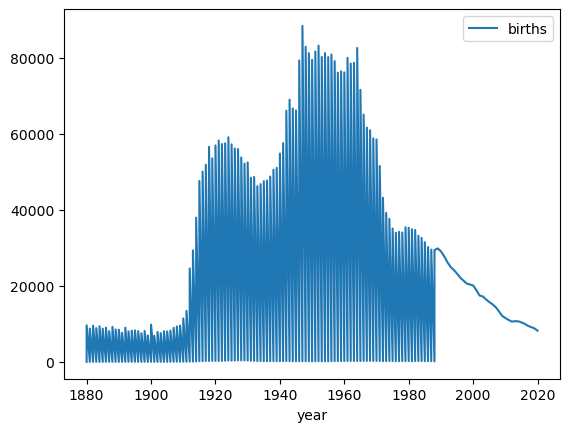

In [99]:
top1000_names[top1000_names.name=='John'].plot(x='year', y='births')

<AxesSubplot:xlabel='year'>

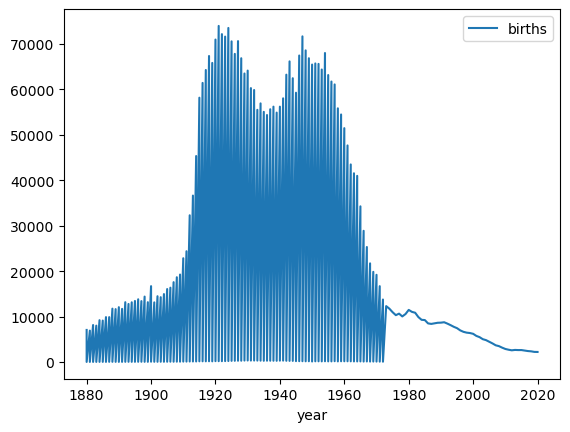

In [100]:
top1000_names[top1000_names.name=='Mary'].plot(x='year', y='births')

<AxesSubplot:xlabel='year'>

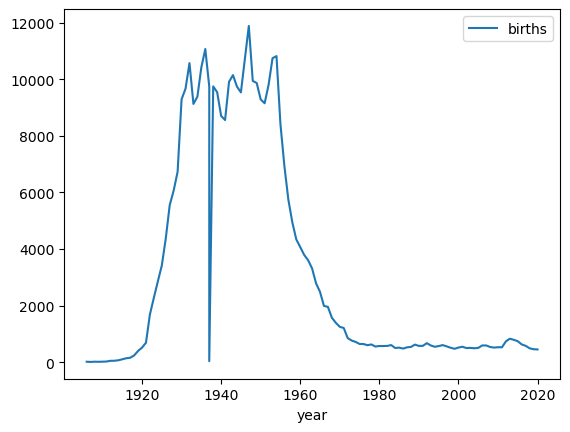

In [101]:
top1000_names[top1000_names.name=='Marilyn'].plot(x='year', y='births')

Looking at your plots, you might conclude that these names have grown out of favor with the American population. 
But the story is more complicated than that, as you will explore in the next part.

## Measuring the increase in naming diversity

One explanation for the decrease in plots is that fewer parents are choosing common names for their children.
One measure of naming diversity is the proportion of births represented by the top 1000 most popular names.

**Part 7**: Plot the proportion of the top 1000 names by year and sex

<AxesSubplot:xlabel='year'>

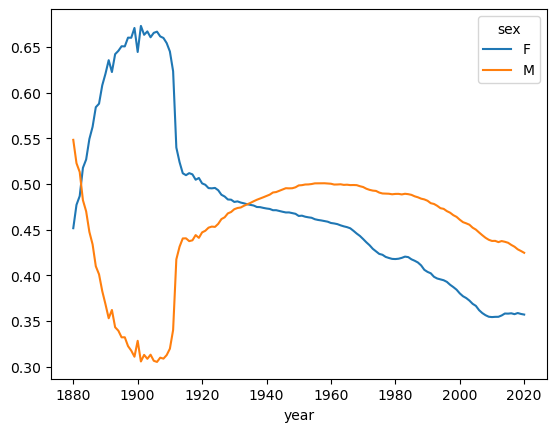

In [110]:
table = pd.pivot_table(data=top1000_names, values = 'prop', index='year', columns='sex', aggfunc='sum')
table.plot()

## 10 most popular 2017 names through the ages

**Part 8**: Find the 10 most popular female names in 2017

In [119]:
indices = top1000_names[(top1000_names.year==2017)&(top1000_names.sex=='F')].prop.sort_values(ascending=False).head(10).index

In [164]:
ten_names = top1000_names.loc[indices,'name']
ten_names = ten_names.to_list()

**Part 9**: Plot the proportions of the 10 most popular female names in 2017 by year

In [157]:
ten_table = pd.pivot_table(data=top1000_names[(top1000_names.sex=='F')],
                           values = 'prop',
                           index='year',
                           columns= 'name'
                          ).fillna(0)

<AxesSubplot:xlabel='year'>

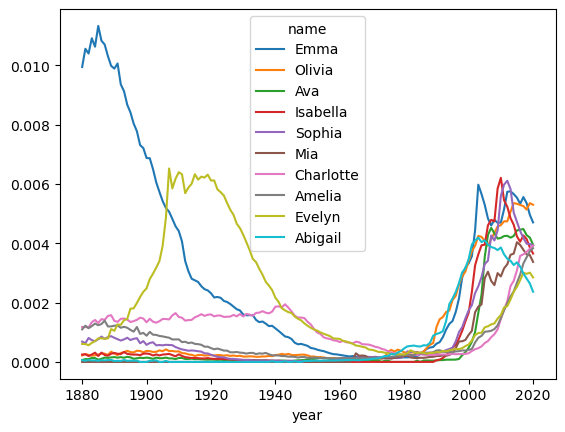

In [160]:
ten_table.loc[:,ten_names].plot()

## Similarity between decades

Here, you will explore the similarity between the set of names given in one particular year and the set of names given 10 years previosly.

The **Jaccard similarity** between sets A and B is the number of
elements in both A and B relative to the number of elements in either A or
B. 
If we let |A| denote the number of elements in the set A, then the Jaccard
similarity is

$$
J(A,B)=\frac{|A \cap B|}{|A\cup B|}
$$

**Part 10**: Find the Jaccard similarity between the following two sets

In [4]:
set1 = {'John','Daniel','Drogo'}
set2 = {'Robert', 'John'}

In [171]:
def Jaccard(A,B):
    return len(A & B) / len(A | B)

In [172]:
Jaccard(set1,set2)

0.25

**Part 11**: Compute the Jaccard similarity between the set of male names given in 2017 and the set of male names given in 2007

In [178]:
male17 = top1000_names[(top1000_names.year==2017)&(top1000_names.sex=='M')].name.to_list()
male07 = top1000_names[(top1000_names.year==2007)&(top1000_names.sex=='M')].name.to_list()

In [180]:
Jaccard(set(male17),set(male07))

0.6356209150326797

**Part 12**: Plot the Jaccard similarity between the set of male names given in one particular year and the set of male names given 10 years previosly by year

In [181]:
lst = []
for i in range(1890, 2021):
    male_current = top1000_names[(top1000_names.year==i)&(top1000_names.sex=='M')].name.to_list()
    male_prev =top1000_names[(top1000_names.year==i-10)&(top1000_names.sex=='M')].name.to_list()
    lst.append(Jaccard(set(male_current), set(male_prev)))

<AxesSubplot:>

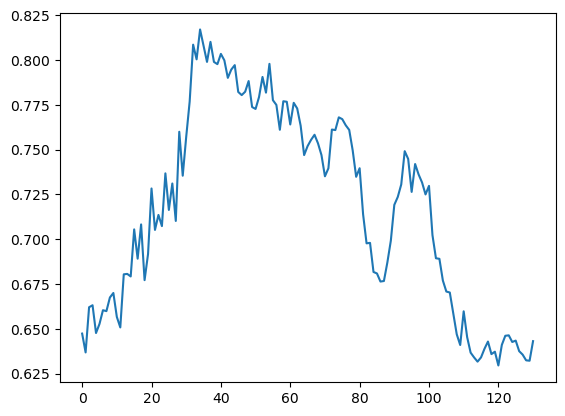

In [185]:
pd.Series(lst)

##  The last letter revolution

It has been argued (see [here](https://www.babynamewizard.com/archives/2007/7/where-all-boys-end-up-nowadays), for example) that the distribution of boy names by final letter has changed significantly over the last 100 years.

**Part 13:** Extract the last letter from the "name" column

In [187]:
def last_letter(string):
    return  string[-1]

top1000_names['last_letter'] = top1000_names.name.apply(last_letter)

In [191]:
male = top1000_names[top1000_names.sex=='M']
male.last_letter

0         n
1         m
2         s
3         s
4         e
         ..
143403    n
143404    o
143405    o
143406    m
143407    n
Name: last_letter, Length: 143408, dtype: object

**Part 14**: Plot the proportion of male names by the last letter for the years 1910, 1960, and 2010

In [199]:
male_table = pd.pivot_table(data = male,
                            values = 'births',
                            index = 'year',
                            columns = 'last_letter',
                            aggfunc = 'sum').fillna(0)
male_table # this table does not yet store the per-year proportions

last_letter,a,b,c,d,e,f,g,h,i,j,...,q,r,s,t,u,v,w,x,y,z
year,,,,,,,,,,,,,,,,,,,,,
1880,776.0,509.0,349.0,9177.0,13493.0,108.0,147.0,4049.0,200.0,0.0,...,0.0,7454.0,18453.0,6948.0,25.0,33.0,853.0,304.0,8371.0,29.0
1881,767.0,470.0,331.0,8386.0,12405.0,83.0,146.0,3765.0,206.0,0.0,...,0.0,7273.0,16369.0,6228.0,26.0,18.0,748.0,267.0,7803.0,8.0
1882,773.0,506.0,349.0,9701.0,14613.0,135.0,146.0,4176.0,207.0,0.0,...,0.0,7988.0,18239.0,7082.0,10.0,43.0,875.0,355.0,8815.0,31.0
1883,757.0,452.0,299.0,8794.0,13191.0,106.0,135.0,3924.0,167.0,0.0,...,0.0,7509.0,16542.0,6754.0,16.0,44.0,794.0,283.0,8281.0,12.0
1884,817.0,496.0,319.0,9856.0,14636.0,131.0,160.0,4241.0,158.0,0.0,...,0.0,8983.0,17710.0,7007.0,15.0,36.0,826.0,343.0,9202.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016,21759.0,25253.0,19986.0,33518.0,102400.0,1388.0,3847.0,90543.0,33872.0,0.0,...,0.0,154341.0,115705.0,50352.0,2334.0,519.0,23772.0,18294.0,82245.0,1014.0
2017,22469.0,22905.0,18710.0,32647.0,98628.0,1402.0,4058.0,87106.0,34426.0,0.0,...,0.0,148418.0,113993.0,51264.0,2751.0,526.0,21516.0,18555.0,76815.0,1268.0
2018,22972.0,21122.0,17615.0,32351.0,95986.0,1129.0,3640.0,85123.0,34847.0,0.0,...,0.0,144587.0,114298.0,51397.0,2878.0,703.0,19105.0,18760.0,73235.0,1252.0


In [200]:
male_table =(male_table.div(male_table.sum(axis=1), axis=0)) # divide each row by the sum of entries in the row
# note that this only gives the proportion of each letter among top 1000 names, given our current dataframe

<AxesSubplot:xlabel='year'>

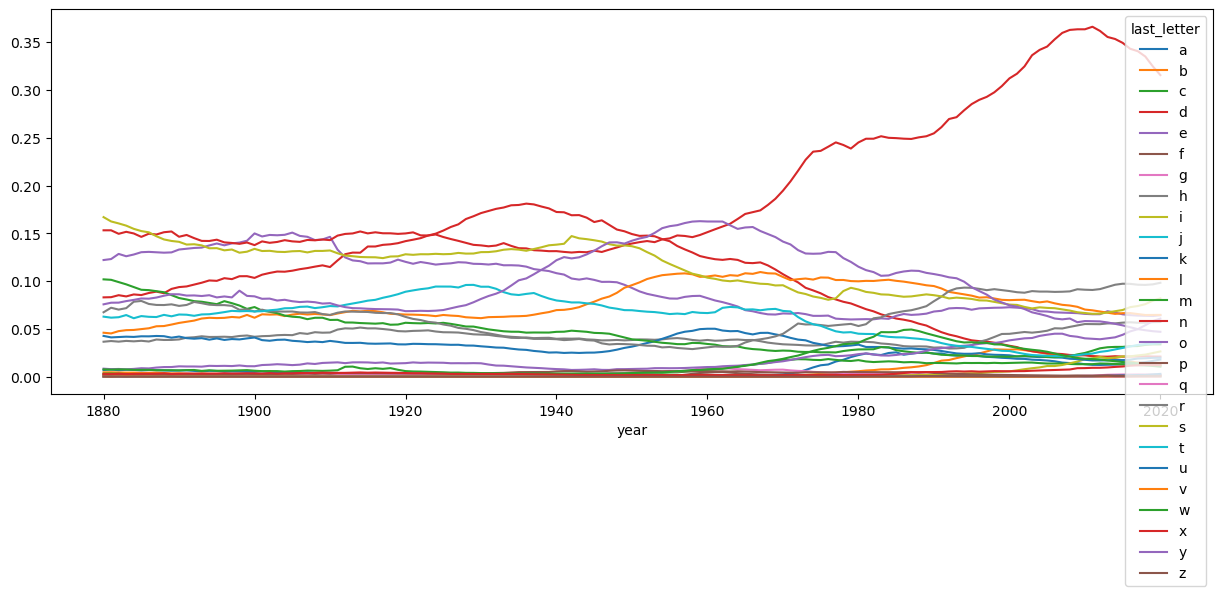

In [213]:
male_table.plot(figsize=(15,5)) # this is the whole plot, I am aware it is not what is being asked for
# but I thought I would include it since it's nice

<AxesSubplot:xlabel='last_letter'>

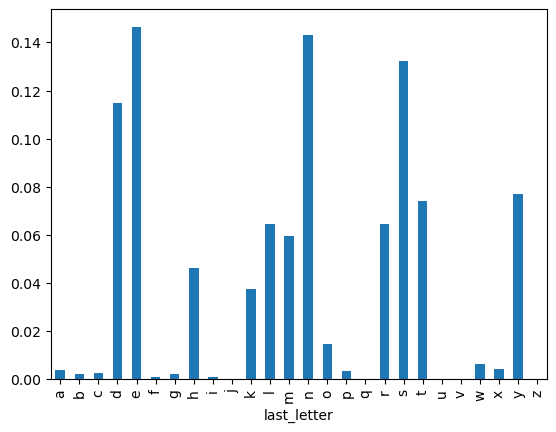

In [208]:
male_table.loc[1910, :].plot.bar()

<AxesSubplot:xlabel='last_letter'>

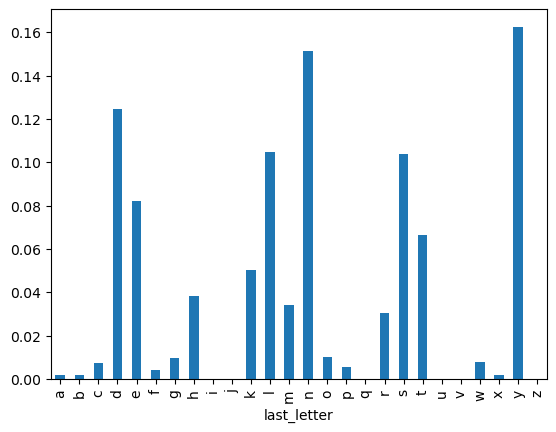

In [209]:
male_table.loc[1960, :].plot.bar()

<AxesSubplot:xlabel='last_letter'>

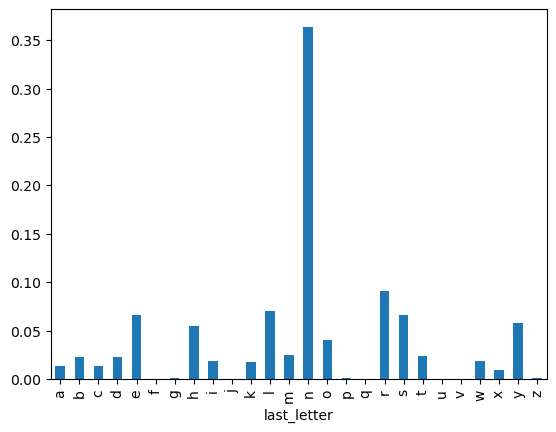

In [210]:
male_table.loc[2010, :].plot.bar()

**Part 15**: Plot the proportions of male names ending in "e", "n", "d", "s" and "y" by year.

<AxesSubplot:xlabel='year'>

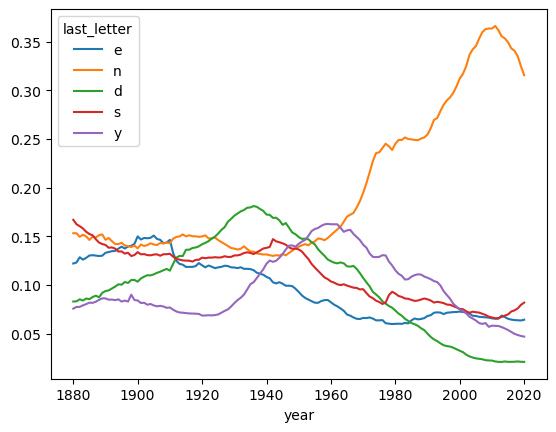

In [215]:
male_table.loc[:,['e','n','d','s','y']].plot()